In [3]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file

import tqdm
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")
# matplolib inline 
%matplotlib inline
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")
from utils.multi_loss import ema_losses

In [4]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()

In [5]:
epochs = 1000
representiation_dim = 64
EXPERIMENT_NAME=r'0.1%basis-set'

In [6]:

CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'dim_mults':(1, 2, 4, 8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    'attention':False, 
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim,
    'encoder_type': 'basis_set', # 'basis_set' or 'vae'

    # encoding types
    'path_type': 'path', # 'path' or 'offset_path'
    'condition_type': 'world_img', # world_distance_field_img, world_img, world_indx

    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': epochs,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },

        'multi_loss_warm_up_steps': 2000,
        'loss_weights':{
            'MSE': 0.5, # best for overfitting 1 sample is 0.004
            'ObstacleFreePathLoss': 0.4, # bround truth avg prefromance is 0.00008 with std 0.27
            'GraphBasedConsistencyLoss': 0.1, # ground truth avg prefromance is 0.00031 with std = 1.09
        },

    # Hyperparameters for diffusion process
    'noise_steps': 1000,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 1000,
    'n_worlds': 1,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
    'single_world_dataset': True,
    'entire_dataset': False,
    'fraction_of_data': 0.001,

    # logging 
    'visualize_every_n_epochs': 1,
    'stats_every_n_steps': 100,
}

In [7]:
from dataset import RobotPathDataset

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

In [9]:
if CONFIG['single_world_dataset']:
    file = 'data\SingleSphere02_all.db'
else:
    file = 'data\SingleSphere02_one-world.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'], entire_dataset=CONFIG['entire_dataset'], fraction_of_data=CONFIG['fraction_of_data'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([1000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:1, samples: 1000
 sample shape torch.Size([64, 2]) with 1000 samples


# Archtechture

### encoder

In [10]:
from model import WorldIndexEmbeder, FlattenEmbeder, VAEXperiment, BPS_Encoder

In [11]:
def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()



In [12]:
# Import pretrained vae model
model_experiment = VAEXperiment.load_from_checkpoint(r'pretrained_models/64-encoder.ckpt')
# model_experiment.freeze()
reset_weights(model_experiment)
vae_model = model_experiment.model
vae_model.to(device)
vae_model.encoder.to(device)

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (1): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(

In [13]:
from model import Encoder
class wrapper_encoder(Encoder):
    def __init__(self, vae_model):
        super(wrapper_encoder, self).__init__()
        self.vae_model = vae_model
    def forward(self, x):
        results = self.vae_model.encode(x)
        mu, log_var = results
        z = self.vae_model.reparameterize(mu, log_var)
        return z

    def decode(self, z):
        return self.vae_model.decode(z)

In [14]:
embedding_dim = CONFIG['encoder_conditional_dim']
# Define the model
sample_input = sample['world_distance_field_img']

In [15]:
if CONFIG['encoder_type'] == 'vae':
    encoder = wrapper_encoder(vae_model)
elif CONFIG['encoder_type'] == 'basis_set':
    encoder = BPS_Encoder(n_bps_points=CONFIG['encoder_conditional_dim'], n_dims=2, minv=0, maxv=64, device=device)

### Model and diffusion

In [16]:
from model import Diffusion, TemporalUnet

In [17]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['noise_steps'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, attention=CONFIG['attention'],device=device)

2
[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256), (256, 512)]
[ models/temporal ] Embedding dimensions: env encoding 32, start_pos encoding 8, end_pos encoding 8, time encoding 16
[(2, 64), (64, 128), (128, 256), (256, 512)]


In [18]:
model.to(device);
model.device

device(type='cuda', index=0)

In [19]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [20]:
# write training loop 
import torch.optim as optim
import torch.nn as nn
from utils.visualize.vae import plot_vae_reconstruciton
from utils.visualize.diffusion import plot_diffusions, plot_noise_and_predicted_noise

In [21]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name=EXPERIMENT_NAME)
logging_manager.log_config(CONFIG);

Logging to logs\0.1%basis-set/23h-26m-19-07-2024/logs.log


In [22]:

START_FROM_CHECKPOINT = True
Checkpoint_file = r"pretrained_models\model-epoch_40-loss_0.033-time_18h-05m-13-07-2024"

optimizer = CONFIG['optimizer'](model.parameters(), **CONFIG['optimizer_kwargs'])
scheduler = CONFIG['scheduler'](optimizer, **CONFIG['scheduler_kwargs'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)
epoch = 0
# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')
    print(f'Restarting from epoch {epoch} with loss {loss}')


Using decoupled weight decay
Restarting from epoch 40 with loss 0.033490926027297974


In [102]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=264, sigma=0.5,device=device)

In [103]:

# diffusion variables
n = 3
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))

x = batch['path']
x = x.to(device)
cond = batch['world_img']
world_imgs = batch['world_img']
cond = cond.to(device)
paths = x
true_paths = batch['og_path']
x.shape, cond.shape

(torch.Size([3, 64, 2]), torch.Size([3, 64, 64]))

In [104]:
samples , intermediates = diffusion.sample_from_paths(model, n=n, paths=paths, cond=cond, normalizer=CONFIG['normalizer'])

263it [00:08, 31.92it/s]


In [105]:
def info(tensor):
    return f'mean {tensor.mean()} std {tensor.std()}, min {tensor.min()} max {tensor.max()}'
info(samples), info(intermediates[0])

('mean 0.39316052198410034 std 0.43487197160720825, min -0.5310423970222473 max 1.0869390964508057',
 'mean 0.02399030700325966 std 0.46383967995643616, min -1.2321090698242188 max 1.3021125793457031')

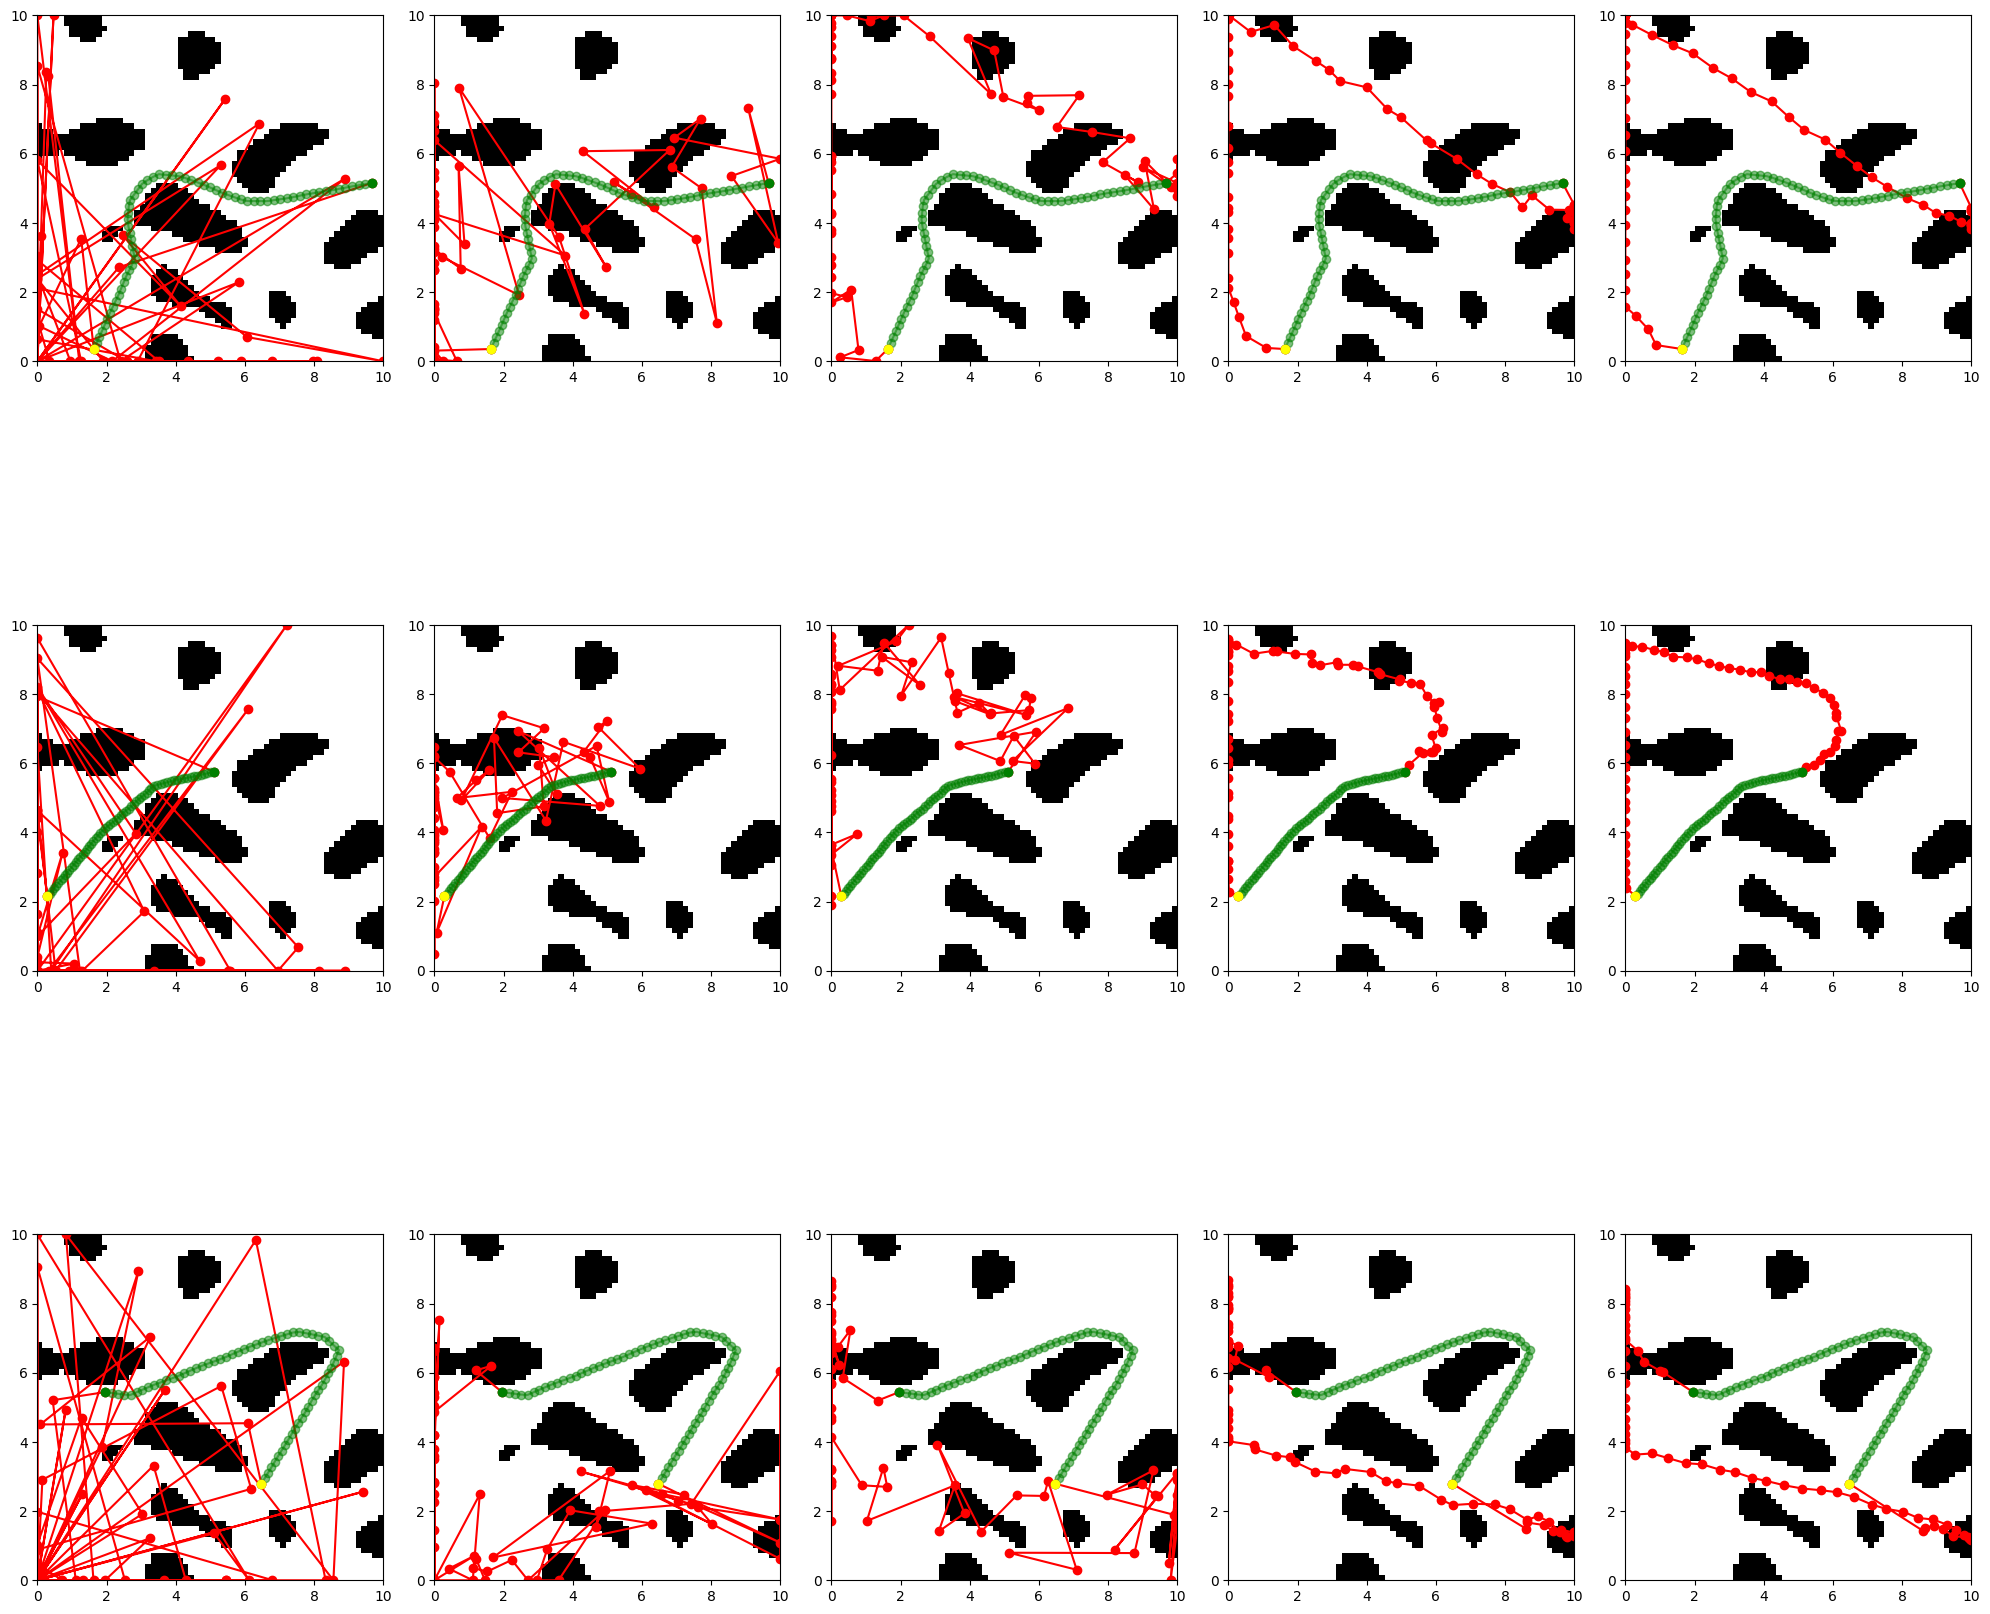

In [106]:
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'], true_paths=true_paths, max_plots=n);

(array([2.55825840e-03, 3.83738760e-03, 5.11651680e-03, 2.55825840e-03,
        2.17451964e-02, 2.81408424e-02, 6.52355892e-02, 1.35587695e-01,
        2.17451964e-01, 3.27457075e-01, 5.03976905e-01, 7.39336678e-01,
        8.65970469e-01, 1.09877198e+00, 1.28040833e+00, 1.43518296e+00,
        1.28296659e+00, 1.13458760e+00, 1.03865291e+00, 8.53179177e-01,
        6.34448083e-01, 4.02925698e-01, 3.15944913e-01, 1.98265026e-01,
        1.08725982e-01, 5.11651680e-02, 2.30243256e-02, 6.39564600e-03,
        6.39564600e-03, 1.27912920e-03]),
 array([-1.23534393, -1.15716575, -1.07898756, -1.00080938, -0.92263119,
        -0.844453  , -0.76627482, -0.68809663, -0.60991845, -0.53174026,
        -0.45356208, -0.37538389, -0.29720571, -0.21902752, -0.14084933,
        -0.06267115,  0.01550704,  0.09368522,  0.17186341,  0.25004159,
         0.32821978,  0.40639796,  0.48457615,  0.56275434,  0.64093252,
         0.71911071,  0.79728889,  0.87546708,  0.95364526,  1.03182345,
         1.11000

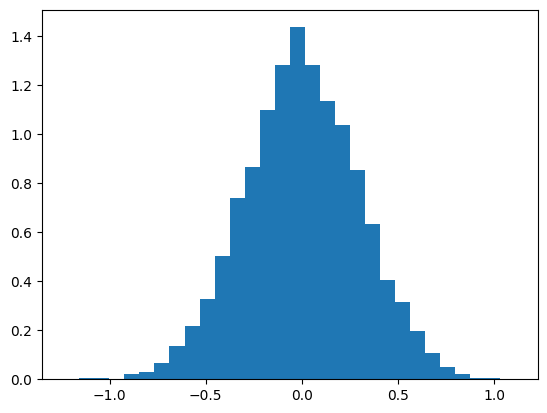

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

mu = 0
sigma = 0.3
n = 10000
values = np.random.randn(n) * sigma + mu
# values = np.clip(values, 0, 1)
# plot them
plt.hist(values, bins=30, density=True)

# Visualisations

## Dataset diversity

In [62]:
# Plot a plot with all paths that start around 5, 5 and end around 10, 10
# get batch of 500 samples
n = 500
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))
batch['path'].shape

torch.Size([500, 64, 2])

In [63]:
paths = batch['path'].to(device)
world_imgs = batch['world_img']
cond = batch['world_img']
cond = cond.to(device)

In [64]:
# remove all paths that do not start around 5, 5 with 2 difference and end around 10, 10 with 2 difference
start = 0.2, 0.2
end =0.6, 0.8
diff = 0.2

start_indx = torch.where((paths[:,0,0] > start[0]-diff) & (paths[:,0,0] < start[0]+diff) & (paths[:,0,1] > start[1]-diff) & (paths[:,0,1] < start[1]+diff))
end_indx = torch.where((paths[:,-1,0] > end[0]-diff) & (paths[:,-1,0] < end[0]+diff) & (paths[:,-1,1] > end[1]-diff) & (paths[:,-1,1] < end[1]+diff))
print(f'Found {len(start_indx[0])} start points and {len(end_indx[0])} end points')
indx = torch.tensor(list(set(start_indx[0].tolist()) & set(end_indx[0].tolist())))
paths_in_der_nahe = paths[indx]
world_imgs = world_imgs[indx]
cond = cond[indx]
paths_in_der_nahe.shape, world_imgs.shape, cond.shape

Found 113 start points and 50 end points


(torch.Size([18, 64, 2]), torch.Size([18, 64, 64]), torch.Size([18, 64, 64]))

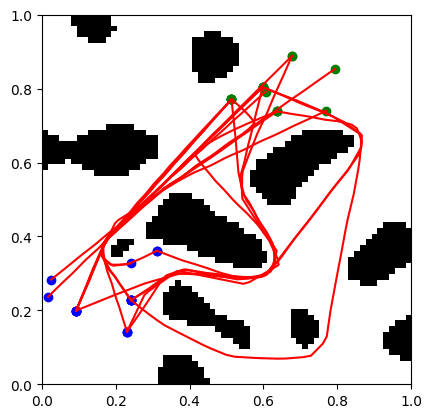

In [74]:
paths_vis = paths_in_der_nahe.cpu().detach().numpy()
# show entore path
plt.figure()
for path in paths_vis:
    plt.plot(path[:,0], path[:,1],c='r')
# show start and end point
plt.scatter(paths_vis[:,0,0], paths_vis[:,0,1], c='b')
plt.scatter(paths_vis[:,-1,0], paths_vis[:,-1,1], c='g')
# show the map
plt.imshow(world_imgs[0].T.cpu().detach().numpy(), extent=[0, 1, 0, 1], origin='lower', cmap='binary')

In [82]:
# sample with constraints
n = 3
constraints = {
    0:torch.tensor(start).to(device) * 10,
    63: torch.tensor(end).to(device) * 10,
}
batch = next(iter(torch.utils.data.DataLoader(dataset, batch_size=n, shuffle=True)))
paths = batch['path'].to(device)
world_imgs = batch['world_img']
cond = batch['world_img']
cond = cond.to(device)


In [83]:
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])

263it [00:13, 19.14it/s]


In [84]:
samples

tensor([[[ 2.0000e-01,  2.0000e-01],
         [ 1.9252e-01,  3.4537e-01],
         [ 7.7875e-02,  2.0316e-01],
         [ 6.2185e-03,  1.9693e-01],
         [-4.2802e-02,  1.8410e-01],
         [-1.2838e-01,  1.2282e-01],
         [-1.9766e-01,  1.1599e-01],
         [-2.9855e-01,  7.0404e-02],
         [-3.5663e-01,  3.7869e-02],
         [-4.4625e-01,  1.9463e-02],
         [-5.1002e-01, -3.4779e-02],
         [-5.7944e-01, -7.2282e-02],
         [-6.6320e-01, -1.1654e-01],
         [-7.2207e-01, -1.9618e-01],
         [-8.0492e-01, -2.2948e-01],
         [-8.4482e-01, -3.3854e-01],
         [-8.8444e-01, -3.8187e-01],
         [-9.1358e-01, -4.7554e-01],
         [-9.2458e-01, -5.4416e-01],
         [-9.3226e-01, -6.3397e-01],
         [-9.2185e-01, -7.0919e-01],
         [-9.2450e-01, -7.9390e-01],
         [-8.7209e-01, -8.6109e-01],
         [-8.3915e-01, -9.4834e-01],
         [-7.5857e-01, -1.0042e+00],
         [-7.1056e-01, -1.0533e+00],
         [-6.2768e-01, -1.1033e+00],
 

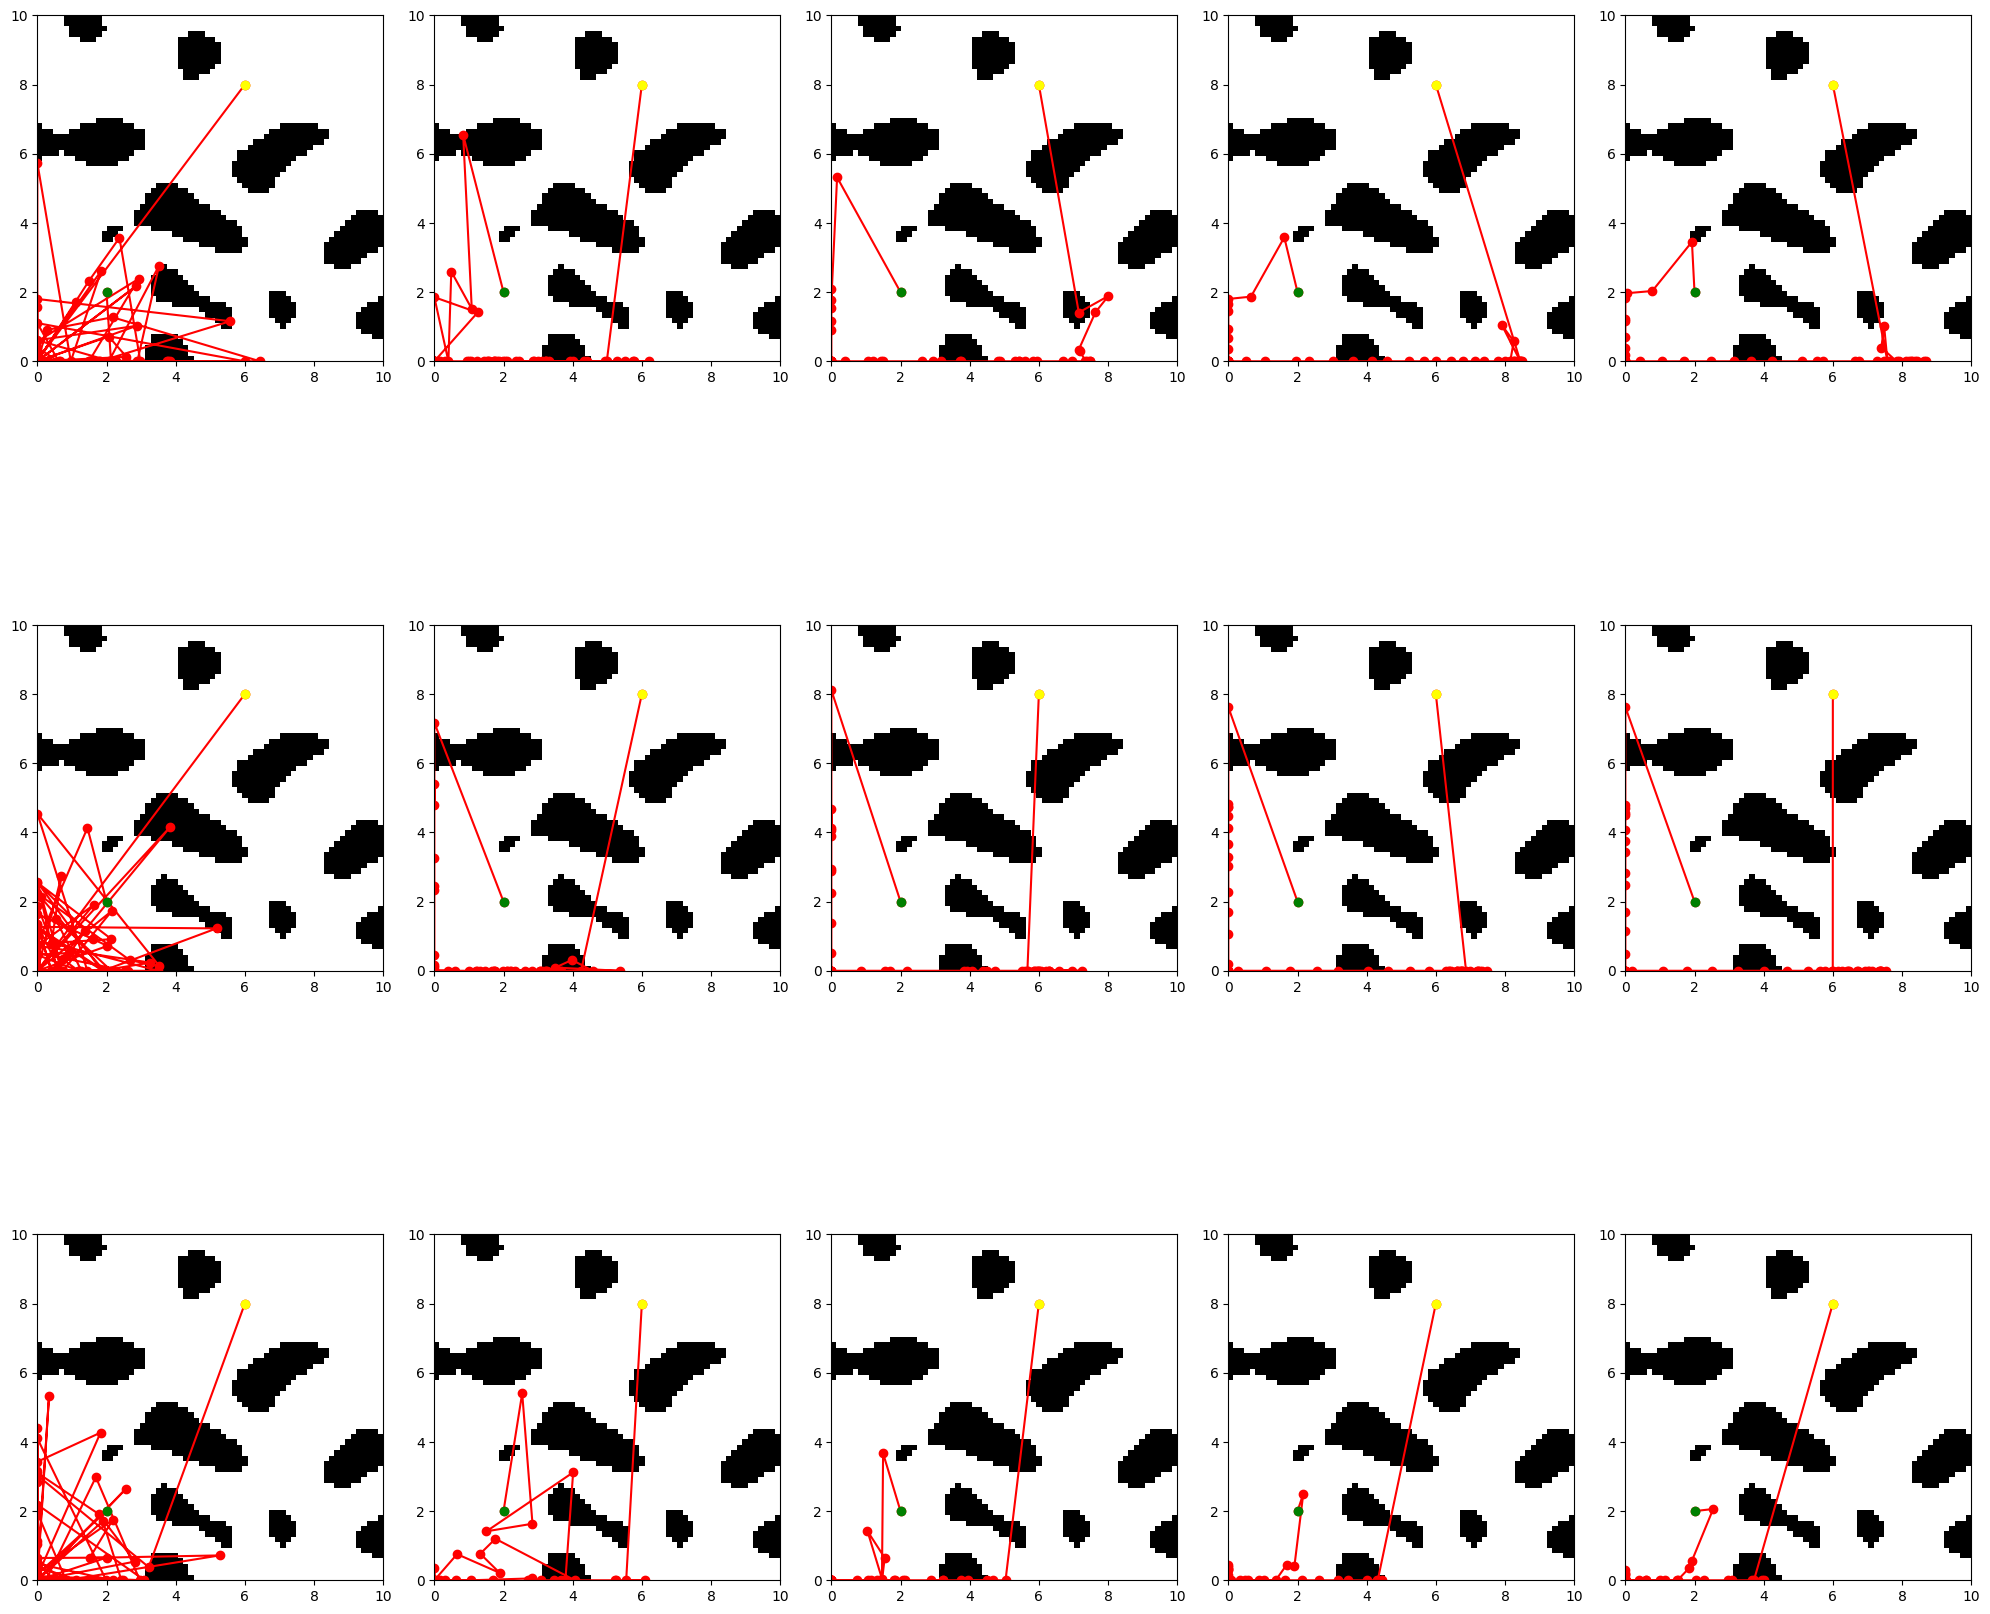

In [85]:

plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);